In [35]:
from typing import Annotated
from typing_extensions import TypedDict
from langchain_openai import ChatOpenAI
from langgraph.graph import START, END
from langgraph.graph.state import StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage
import os
from dotenv import load_dotenv
load_dotenv()

True

In [36]:
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

In [42]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("llama-3.1-8b-instant", model_provider="groq")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001E97FD089D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001E97FD09350>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [47]:
class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [53]:
## Graph with tool call
from langchain_core.tools import tool

@tool
def add(a:float, b:float) -> float:
    """Add two numbers."""
    return a + b

tools = [add]
tool_node = ToolNode([add])
llm_with_tool = llm.bind_tools([add])

def call_llm_model(state:State):
    return {"messages": [llm_with_tool.invoke(state['messages'])]}


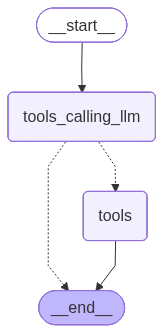

In [55]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node Definition
def call_llm_model(state:State):
    return {"messages": [llm_with_tool.invoke(state['messages'])]}

## Build Graph
builder = StateGraph(State)
builder.add_node("tools_calling_llm", call_llm_model)
builder.add_node("tools", ToolNode(tools))

## Edges
builder.add_edge(START, "tools_calling_llm")
builder.add_conditional_edges(
    "tools_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools.
    # Is the latest message (result) from assistant is not a tools call -> tools_condition routes to END.
    tools_condition
)
builder.add_edge("tools", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [58]:
response = graph.invoke({"messages": "What is 2 + 5?"})
response

{'messages': [HumanMessage(content='What is 2 + 5?', additional_kwargs={}, response_metadata={}, id='6b5b40ac-080e-4569-a131-0aac900932d9'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'fkcdc5gkr', 'function': {'arguments': '{"a":2,"b":5}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 220, 'total_tokens': 238, 'completion_time': 0.024344674, 'completion_tokens_details': None, 'prompt_time': 0.012081907, 'prompt_tokens_details': None, 'queue_time': 0.276633278, 'total_time': 0.036426581}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_03e8423237', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d6ce7-3e0e-79b3-95be-d1df2a944176-0', tool_calls=[{'name': 'add', 'args': {'a': 2, 'b': 5}, 'id': 'fkcdc5gkr', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 220, 'output_tokens': 18, 'to